# Amazon Fashion Collaborative Filtering: Comprehensive Academic Baseline

This notebook documents the explicit CF baseline in the context of the real production architecture: upstream iterative **k-core filtering (user_k >= 5, item_k >= 5)** is used to isolate warm entities for CF/Two-Tower modeling, while cold entities are handled by a separate content-based layer.


In [ ]:
# If surprise import fails due to NumPy ABI mismatch, run in notebook terminal then restart kernel:
# %pip install --upgrade --force-reinstall "numpy<2" "scikit-surprise==1.1.4" matplotlib seaborn


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

SURPRISE_OK = True
SURPRISE_IMPORT_ERROR = None
try:
    from surprise import Dataset, Reader, SVD, KNNWithMeans, accuracy
    from surprise.model_selection import GridSearchCV
except Exception as e:
    SURPRISE_OK = False
    SURPRISE_IMPORT_ERROR = e
    print("scikit-surprise import failed:")
    print(e)
    print("\nLikely cause: NumPy ABI mismatch (NumPy 2.x vs module compiled for NumPy 1.x).")
    print("Run: pip install --upgrade --force-reinstall \"numpy<2\" \"scikit-surprise==1.1.4\"")


In [3]:
@dataclass
class Config:
    train_path: str = "mini_train.csv"
    test_path: str = "mini_test.csv"
    file_format: str = "csv"

    user_col: str = "user_id"
    item_col: str = "parent_asin"
    rating_col: str = "rating"

    rating_scale: Tuple[int, int] = (1, 5)
    random_state: int = 42

cfg = Config()
cfg


Config(train_path='mini_train.csv', test_path='mini_test.csv', file_format='csv', user_col='user_id', item_col='parent_asin', rating_col='rating', rating_scale=(1, 5), random_state=42)

In [4]:
def ensure_surprise() -> None:
    if not SURPRISE_OK:
        raise RuntimeError(
            "scikit-surprise not importable. Run: pip install --upgrade --force-reinstall \"numpy<2\" \"scikit-surprise==1.1.4\" and restart kernel."
        ) from SURPRISE_IMPORT_ERROR


def resolve_data_path(path: str) -> Path:
    raw = Path(path).expanduser()
    if raw.is_absolute() and raw.exists():
        return raw

    cwd = Path.cwd()
    candidates = [
        cwd / raw,
        cwd / raw.name,
        cwd / "research" / raw,
        cwd / "research" / raw.name,
    ]
    for parent in cwd.parents:
        candidates.extend([
            parent / raw,
            parent / raw.name,
            parent / "research" / raw,
            parent / "research" / raw.name,
        ])

    seen = set()
    deduped = []
    for c in candidates:
        k = str(c)
        if k not in seen:
            seen.add(k)
            deduped.append(c)

    for c in deduped:
        if c.exists():
            return c

    checked = "\n".join(f"- {c}" for c in deduped[:12])
    raise FileNotFoundError(f"Could not find {path!r}. Checked:\n{checked}")


def read_df(path: str, fmt: str) -> pd.DataFrame:
    resolved = resolve_data_path(path)
    if fmt == "csv":
        return pd.read_csv(resolved)
    if fmt == "parquet":
        return pd.read_parquet(resolved)
    raise ValueError("fmt must be csv or parquet")


def prepare(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    cols = [cfg.user_col, cfg.item_col, cfg.rating_col]
    out = df[cols].copy()
    out[cfg.rating_col] = pd.to_numeric(out[cfg.rating_col], errors="coerce")
    out = out.dropna(subset=cols)
    out = out.drop_duplicates(subset=[cfg.user_col, cfg.item_col], keep="last")
    return out


def matrix_density(df: pd.DataFrame, user_col: str, item_col: str) -> float:
    possible = df[user_col].nunique() * df[item_col].nunique()
    return len(df) / possible if possible else 0.0


def estimate_dense_similarity_gb(n_entities: int, dtype_bytes: int = 4) -> float:
    return (n_entities ** 2) * dtype_bytes / (1024 ** 3)


def recommend_popular(pop_df: pd.DataFrame, top_n: int, user_id: str | None = None) -> pd.DataFrame:
    recs = pop_df.head(top_n).copy()
    if user_id is not None:
        recs.insert(0, "user_id", user_id)
    return recs


In [5]:
train_raw = read_df(cfg.train_path, cfg.file_format)
test_raw = read_df(cfg.test_path, cfg.file_format)

train_df = prepare(train_raw, cfg)
test_df = prepare(test_raw, cfg)
combined_df = pd.concat([train_df, test_df], ignore_index=True)

print("Train shape   :", train_df.shape)
print("Test shape    :", test_df.shape)
print("Combined shape:", combined_df.shape)
display(combined_df.head())


Train shape   : (250000, 3)
Test shape    : (20282, 3)
Combined shape: (270282, 3)


,user_id,parent_asin,rating
0,AGTQVJKZR5MFMT75CBTM6BKUBGJQ,B006455HKI,5.0
1,AFF5RQJVDUQENXFOFMPN3MCXARFA,B005GCCJJW,4.0
2,AFMPVZ7WMJVPGSICTHHYIODNNABQ,B008R6PKBS,5.0
3,AF2YT7L5ZDIT4V57RZ2XTY7SAPNQ,B0C15H1PGM,2.0
4,AF6CO6WVKTOV7LG5ODL4CMJGSY4Q,B005033D0Q,4.0


## 1. Exploratory Data Analysis (EDA)

Check missing values and rating distribution (bar + pie).


Missing values by column:


user_id        0
parent_asin    0
rating         0
dtype: int64

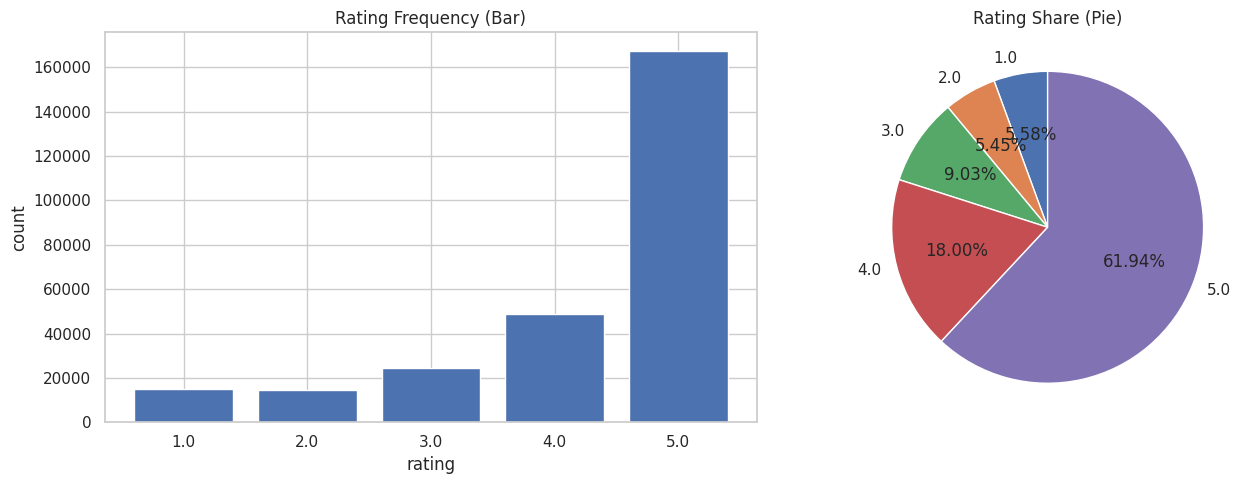

,count,percent
rating,,
1.0,15083,5.580
2.0,14731,5.450
3.0,24409,9.031
4.0,48639,17.996
5.0,167420,61.943


In [6]:
print("Missing values by column:")
display(combined_df.isna().sum())

rating_counts = combined_df[cfg.rating_col].value_counts().sort_index()
rating_pct = (rating_counts / rating_counts.sum()) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(rating_counts.index.astype(str), rating_counts.values)
ax[0].set_title("Rating Frequency (Bar)")
ax[0].set_xlabel("rating")
ax[0].set_ylabel("count")

ax[1].pie(rating_counts.values, labels=rating_counts.index.astype(str), autopct="%1.2f%%", startangle=90)
ax[1].set_title("Rating Share (Pie)")

plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": rating_counts, "percent": rating_pct.round(3)}))


## 2. Sparsity & Data Destruction Proof (NO TRUNCATION)

We compute the combined matrix density and show hypothetical row/user loss under thresholds (`<5`, `<50`) as a diagnostic proof.

**Architecture context:** in the real system, `k-core=5` is not an academic shortcut; it is the routing boundary between cold and warm entities.

- **Cold entities (<5 interactions):** routed to Content-Based Filtering (semantic/heuristic retrieval).
- **Warm entities (>=5 interactions):** routed to Collaborative Filtering and Two-Tower embedding models.


In [7]:
density_combined = matrix_density(combined_df, cfg.user_col, cfg.item_col)
n_rows = len(combined_df)
n_users = combined_df[cfg.user_col].nunique()
n_items = combined_df[cfg.item_col].nunique()

print(f"Combined density: {density_combined:.12f} ({100*density_combined:.6f}%)")
print(f"Combined rows/users/items: {n_rows:,} / {n_users:,} / {n_items:,}")

user_counts = combined_df[cfg.user_col].value_counts()
proof_rows = []
for threshold in [5, 50]:
    keep_users = user_counts[user_counts >= threshold].index
    hypothetically_kept = combined_df[combined_df[cfg.user_col].isin(keep_users)]

    kept_rows = len(hypothetically_kept)
    destroyed_rows = n_rows - kept_rows
    destroyed_rows_pct = (destroyed_rows / n_rows) * 100 if n_rows else 0.0

    kept_users = hypothetically_kept[cfg.user_col].nunique()
    destroyed_users = n_users - kept_users
    destroyed_users_pct = (destroyed_users / n_users) * 100 if n_users else 0.0

    density_if_applied = matrix_density(hypothetically_kept, cfg.user_col, cfg.item_col)

    proof_rows.append({
        "min_ratings_threshold": threshold,
        "destroyed_users_pct": round(destroyed_users_pct, 3),
        "destroyed_rows_pct": round(destroyed_rows_pct, 3),
        "density_if_filter_applied": density_if_applied,
    })

proof_df = pd.DataFrame(proof_rows)
display(proof_df)

print("No truncation applied: modeling will use 100% of mini_train and 100% of mini_test.")


Combined density: 0.000009123926 (0.000912%)
Combined rows/users/items: 270,282 / 225,239 / 131,520


,min_ratings_threshold,destroyed_users_pct,destroyed_rows_pct,density_if_filter_applied
0,5,99.465,97.15,0.000978
1,50,100.000,100.00,0.000000


No truncation applied: modeling will use 100% of mini_train and 100% of mini_test.


### Data Destruction vs. Density (Architecture Interpretation)

The destruction table should be interpreted as a routing analysis, not as blanket data removal from the recommender system.

- At small sample scale, `k=5` is a practical warm-signal cutoff and is usually manageable.
- At very large scale, `k=50` can collapse huge long-tail populations and is typically too aggressive for production routing.
- In this architecture, low-interaction entities are **not discarded globally**; they are served by the content-based stage, while CF evaluation stays focused on warm entities.


## 3. Preserve Temporal Split (NO RANDOM SPLIT)

We do not use `train_test_split`.
- `mini_train.csv` is used **exclusively** for training.
- `mini_test.csv` is used **exclusively** for testing.

### Data Leakage & Time-Travel
The datasets are chronologically sampled from larger review history. Random shuffling can leak future behavior into training and artificially inflate offline scores (time-travel leakage).


In [8]:
ensure_surprise()

# Train set: full mini_train only
reader = Reader(rating_scale=cfg.rating_scale)
surprise_train_data = Dataset.load_from_df(train_df[[cfg.user_col, cfg.item_col, cfg.rating_col]], reader)
trainset = surprise_train_data.build_full_trainset()

# Test set: direct list-of-tuples from mini_test
test_tuples_raw = list(test_df[[cfg.user_col, cfg.item_col, cfg.rating_col]].itertuples(index=False, name=None))

# Warm-start diagnostics
train_users = set(train_df[cfg.user_col].unique())
train_items = set(train_df[cfg.item_col].unique())

unknown_user_rows = (~test_df[cfg.user_col].isin(train_users)).sum()
unknown_item_rows = (~test_df[cfg.item_col].isin(train_items)).sum()

print("Trainset users/items/ratings:", trainset.n_users, trainset.n_items, trainset.n_ratings)
print("Raw test tuples:", len(test_tuples_raw))
print("Unknown-user rows in test:", int(unknown_user_rows))
print("Unknown-item rows in test:", int(unknown_item_rows))

# strict warm-start isolation (as designed in this dataset)
test_eval_df = test_df[test_df[cfg.user_col].isin(train_users) & test_df[cfg.item_col].isin(train_items)].copy()
test_tuples = list(test_eval_df[[cfg.user_col, cfg.item_col, cfg.rating_col]].itertuples(index=False, name=None))
print("Warm-start test tuples used for CF:", len(test_tuples))


Trainset users/items/ratings: 225239 131520 250000
Raw test tuples: 20282
Unknown-user rows in test: 0
Unknown-item rows in test: 0
Warm-start test tuples used for CF: 20282


### Warm-Start Isolation

CF is evaluated strictly on known warm entities. The provided test split is engineered for warm-start behavior (test users/items exist in train).

This separation is intentional in the two-stage system: cold-start handling belongs to the content-based engine, while CF/Two-Tower are evaluated where dense interaction signals exist.


## 4. Popularity Baseline

Non-personalized global baseline from training data only.


In [9]:
popularity_df = (
    train_df.groupby(cfg.item_col)
    .agg(rating_count=(cfg.rating_col, "count"), rating_mean=(cfg.rating_col, "mean"))
    .reset_index()
)
popularity_df["score"] = popularity_df["rating_count"] * popularity_df["rating_mean"]
popularity_df = popularity_df.sort_values(["rating_count", "rating_mean", "score"], ascending=False).reset_index(drop=True)
display(popularity_df.head(10))


,parent_asin,rating_count,rating_mean,score
0,B07TVHSDMQ,1000,4.413000,4413.0
1,B005GI8UZ8,382,4.628272,1768.0
2,B08513YB2T,344,4.514535,1553.0
3,B000DZZFUW,256,4.683594,1199.0
4,B0018OMK82,231,4.216450,974.0
5,B09TQ58RLF,220,4.722727,1039.0
6,B0BLXPNPQV,203,4.325123,878.0
7,B001EJMRKW,184,4.505435,829.0
8,B096GJ5TC7,178,4.662921,830.0
9,B004EIHD18,177,4.508475,798.0


## 5. User-User Collaborative Filtering (KNNWithMeans, user_based=True)

We train/evaluate on temporal split (train mini_train, test mini_test warm-start tuples).


### OOM Failures at Scale

KNN-based CF relies on similarity structures that scale quadratically with user/item cardinality.

- User-user similarity memory grows as `O(n_users^2)`
- Item-item similarity memory grows as `O(n_items^2)`

At production scale this can require massive RAM and often leads to OOM failures.


In [10]:
n_users_combined = combined_df[cfg.user_col].nunique()
n_items_combined = combined_df[cfg.item_col].nunique()

uu_gb = estimate_dense_similarity_gb(n_users_combined, dtype_bytes=4)
ii_gb = estimate_dense_similarity_gb(n_items_combined, dtype_bytes=4)

print(f"Unique users: {n_users_combined:,}")
print(f"Unique items: {n_items_combined:,}")
print(f"Estimated dense user-user matrix RAM (float32): {uu_gb:,.2f} GB")
print(f"Estimated dense item-item matrix RAM (float32): {ii_gb:,.2f} GB")
print("These are lower-bound estimates excluding Python/object overhead.")


Unique users: 225,239
Unique items: 131,520
Estimated dense user-user matrix RAM (float32): 188.99 GB
Estimated dense item-item matrix RAM (float32): 64.44 GB
These are lower-bound estimates excluding Python/object overhead.


In [11]:
ensure_surprise()
sim_uu = {"name": "cosine", "user_based": True}
try:
    uu_model = KNNWithMeans(k=20, sim_options=sim_uu, verbose=False)
    uu_model.fit(trainset)
    uu_preds = uu_model.test(test_tuples)
    uu_rmse = accuracy.rmse(uu_preds, verbose=False)
    uu_mae = accuracy.mae(uu_preds, verbose=False)
    print(f"User-User RMSE: {uu_rmse:.4f}")
    print(f"User-User MAE : {uu_mae:.4f}")
except Exception as e:
    uu_rmse, uu_mae = np.nan, np.nan
    print("User-User KNNWithMeans failed (likely memory/computation bottleneck at this cardinality).")
    print(type(e).__name__, str(e)[:500])


User-User KNNWithMeans failed (likely memory/computation bottleneck at this cardinality).
MemoryError Unable to allocate 378. GiB for an array with shape (225239, 225239) and data type float64


## 6. Item-Item Collaborative Filtering (KNNWithMeans, user_based=False)


In [12]:
ensure_surprise()
sim_ii = {"name": "cosine", "user_based": False}
try:
    ii_model = KNNWithMeans(k=20, sim_options=sim_ii, verbose=False)
    ii_model.fit(trainset)
    ii_preds = ii_model.test(test_tuples)
    ii_rmse = accuracy.rmse(ii_preds, verbose=False)
    ii_mae = accuracy.mae(ii_preds, verbose=False)
    print(f"Item-Item RMSE: {ii_rmse:.4f}")
    print(f"Item-Item MAE : {ii_mae:.4f}")
except Exception as e:
    ii_rmse, ii_mae = np.nan, np.nan
    print("Item-Item KNNWithMeans failed (likely memory/computation bottleneck at this cardinality).")
    print(type(e).__name__, str(e)[:500])


Item-Item KNNWithMeans failed (likely memory/computation bottleneck at this cardinality).
MemoryError Unable to allocate 129. GiB for an array with shape (131520, 131520) and data type float64


## 7. Model-Based CF & Hyperparameter Tuning (SVD + GridSearchCV)

**RMSE limitation:** predicting exact star values is often less aligned with e-commerce goals than ranking relevance (e.g., NDCG/Recall@K).


In [13]:
ensure_surprise()
param_grid = {
    "n_epochs": [10, 20],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.1],
}
gs = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=3, n_jobs=1)
gs.fit(surprise_train_data)

best_params = gs.best_params["rmse"]
print("Best SVD params (RMSE):", best_params)
print("Best CV RMSE:", gs.best_score["rmse"])

svd_model = SVD(**best_params, random_state=cfg.random_state)
svd_model.fit(trainset)
svd_preds = svd_model.test(test_tuples)
svd_rmse = accuracy.rmse(svd_preds, verbose=False)
svd_mae = accuracy.mae(svd_preds, verbose=False)
print(f"SVD RMSE: {svd_rmse:.4f}")
print(f"SVD MAE : {svd_mae:.4f}")

metrics_df = pd.DataFrame([
    {"model": "KNN User-User", "RMSE": uu_rmse, "MAE": uu_mae},
    {"model": "KNN Item-Item", "RMSE": ii_rmse, "MAE": ii_mae},
    {"model": "SVD (best)", "RMSE": svd_rmse, "MAE": svd_mae},
])
display(metrics_df.sort_values("RMSE"))


Best SVD params (RMSE): {'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}
Best CV RMSE: 1.1513512228379768
SVD RMSE: 1.2686
SVD MAE : 0.9804


,model,RMSE,MAE
2,SVD (best),1.26865,0.980389
0,KNN User-User,NaN,NaN
1,KNN Item-Item,NaN,NaN


## 8. Qualitative User Comparison

Compare Top-5 Popularity vs Top-5 Personalized SVD recommendations for one user from test set.


In [14]:
target_user = test_eval_df[cfg.user_col].value_counts().idxmax()
print("Selected user_id:", target_user)

pop_top5 = recommend_popular(popularity_df[[cfg.item_col, "rating_count", "rating_mean", "score"]], top_n=5, user_id=target_user)
print("\nTop-5 Popularity Recommendations:")
display(pop_top5)

seen_items = set(train_df.loc[train_df[cfg.user_col] == target_user, cfg.item_col])
candidate_items = [iid for iid in train_df[cfg.item_col].unique() if iid not in seen_items]

svd_scores = []
for iid in candidate_items:
    svd_scores.append((iid, svd_model.predict(target_user, iid).est))

svd_top5 = pd.DataFrame(sorted(svd_scores, key=lambda x: x[1], reverse=True)[:5], columns=[cfg.item_col, "predicted_rating"])
svd_top5.insert(0, cfg.user_col, target_user)
print("Top-5 SVD Recommendations:")
display(svd_top5)


Selected user_id: AEQWLV4R5U2WXL4CGNFUQPUVIQNA

Top-5 Popularity Recommendations:


,user_id,parent_asin,rating_count,rating_mean,score
0,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B07TVHSDMQ,1000,4.413000,4413.0
1,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B005GI8UZ8,382,4.628272,1768.0
2,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B08513YB2T,344,4.514535,1553.0
3,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B000DZZFUW,256,4.683594,1199.0
4,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B0018OMK82,231,4.216450,974.0


Top-5 SVD Recommendations:


,user_id,parent_asin,predicted_rating
0,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B01FSIKPNK,4.943996
1,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B00FLRKDC2,4.943305
2,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B078GPLYJB,4.906223
3,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B085XYCBF7,4.898547
4,AEQWLV4R5U2WXL4CGNFUQPUVIQNA,B000ZOXIL4,4.896823


## Educational Summary

1. Temporal split is preserved to avoid time-travel leakage (future reviews influencing past predictions).
2. The real production pipeline uses upstream iterative `k-core=5` to isolate warm entities for CF/Two-Tower training and evaluation.
3. Cold entities (`<5` interactions) are routed to the content-based layer, so low-signal traffic is handled rather than ignored.
4. The `<5` and `<50` destruction proof is diagnostic: `k=5` is a practical routing threshold, while `k=50` can be overly destructive at this scale.
5. KNN similarity methods remain O(N²) memory patterns and can OOM at production cardinalities.
6. RMSE/MAE are useful diagnostics, but production recommendation quality should still be judged with ranking metrics (NDCG/Recall@K/HR@K).
